In [19]:
import pandas as pd
from sqlalchemy import create_engine

# 1. TUS CREDENCIALES (Ajusta si tu BD tiene contraseña)
usuario = "root"
password = "" 
host = "localhost"
puerto = "3306"
nombre_bd = "db_ia_data_science2" # Nombre que aparece en tu imagen

# 2. CREAR LA CONEXIÓN
engine = create_engine(f"mysql+mysqlconnector://{usuario}:{password}@{host}:{puerto}/{nombre_bd}")

# 4. VERIFICACIÓN
print("¡Conexión exitosa!")



¡Conexión exitosa!


In [21]:
from sqlalchemy import text

tablas = [
    't_clientes', 't_facturas', 't_inventario', 't_pedido', 
    't_referencias', 't_tallas', 't_tiendas', 't_ventas', 't_ciudades'
]

with engine.connect() as connection:
    for tabla in tablas:
        print(f"\n--- Revisando tabla: {tabla} ---")
        
        try:
            # 1. Obtenemos los nombres de las columnas
            result = connection.execute(text(f"SHOW COLUMNS FROM {tabla}"))
            # Extraemos el primer elemento de cada fila (el nombre)
            columnas = [row[0] for row in result]
            
            for col in columnas: # <--- Cambiado 'en' por 'in'
                # 2. Contamos registros con contenido real
                query_check = text(f"""
                    SELECT COUNT(*) FROM {tabla} 
                    WHERE `{col}` IS NOT NULL 
                    AND `{col}` != '0' 
                    AND `{col}` != 0 
                    AND `{col}` != ''
                """)
                
                tiene_datos = connection.execute(query_check).scalar()
                
                if tiene_datos == 0:
                    try:
                        # 3. Borrado de columna vacía
                        print(f"   [!] Eliminando: {col} (vacía/ceros)")
                        connection.execute(text(f"ALTER TABLE {tabla} DROP COLUMN `{col}`"))
                        connection.commit() 
                    except Exception as e:
                        print(f"   [X] No se pudo borrar {col}: {e}")
                else:
                    print(f"   [OK] {col} conservada ({tiene_datos} datos)")
        
        except Exception as e:
            print(f"Error al procesar la tabla {tabla}: {e}")

print("\n✅ ¡Limpieza masiva completada!")



--- Revisando tabla: t_clientes ---
   [OK] Id_Cliente conservada (26684 datos)
   [!] Eliminando: Avatar_Cliente (vacía/ceros)
   [OK] tipodocumento conservada (1 datos)
   [OK] Documento_Cliente conservada (26682 datos)
   [!] Eliminando: Nom_Cliente (vacía/ceros)
   [OK] Ape_Cliente conservada (2 datos)
   [OK] Dir_Cliente conservada (72 datos)
   [OK] Ciudad_Id_Ciudad conservada (26684 datos)
   [OK] Correo_Cliente conservada (17 datos)
   [!] Eliminando: Tel_Cliente (vacía/ceros)
   [!] Eliminando: Cel1_Cliente (vacía/ceros)
   [!] Eliminando: Cel2_Cliente (vacía/ceros)
   [OK] Tipo_Cliente conservada (26684 datos)
   [!] Eliminando: Largo_Manga (vacía/ceros)
   [OK] Largo_Camisa conservada (1 datos)
   [!] Eliminando: Espalda (vacía/ceros)
   [!] Eliminando: Pecho (vacía/ceros)
   [!] Eliminando: Abdomen (vacía/ceros)
   [!] Eliminando: Contorno_Cuello (vacía/ceros)
   [OK] Cintura conservada (1 datos)
   [!] Eliminando: Cadera (vacía/ceros)
   [!] Eliminando: Tiro (vacía/ceros)

In [22]:
from sqlalchemy import text

tablas = [
    't_clientes', 't_facturas', 't_inventario', 't_pedido', 
    't_referencias', 't_tallas', 't_tiendas', 't_ventas', 't_ciudades'
]

with engine.connect() as connection:
    for tabla in tablas:
        print(f"\n--- Analizando tabla: {tabla} ---")
        
        try:
            # 1. Obtener nombres de columnas
            result = connection.execute(text(f"SHOW COLUMNS FROM {tabla}"))
            columnas = [row[0] for row in result]
            
            for col in columnas:
                # 2. Contar registros con contenido real (no nulo, no cero, no vacío)
                query_check = text(f"""
                    SELECT COUNT(*) FROM {tabla} 
                    WHERE `{col}` IS NOT NULL 
                    AND `{col}` != '0' 
                    AND `{col}` != 0 
                    AND `{col}` != ''
                """)
                
                conteo = connection.execute(query_check).scalar()
                
                # 3. Si tiene entre 1 y 5 casos, o está vacía (0), se elimina la columna
                if conteo <= 5:
                    try:
                        print(f"   [!] Eliminando columna '{col}': Solo tiene {conteo} casos.")
                        connection.execute(text(f"ALTER TABLE {tabla} DROP COLUMN `{col}`"))
                        connection.commit()
                    except Exception as e:
                        print(f"   [X] Error al eliminar {col}: {e}")
                else:
                    print(f"   [OK] '{col}' se mantiene (tiene {conteo} casos).")
                    
        except Exception as e:
            print(f"Error procesando la tabla {tabla}: {e}")

print("\n✅ Proceso de filtrado y limpieza terminado.")



--- Analizando tabla: t_clientes ---
   [OK] 'Id_Cliente' se mantiene (tiene 26684 casos).
   [!] Eliminando columna 'tipodocumento': Solo tiene 1 casos.
   [OK] 'Documento_Cliente' se mantiene (tiene 26682 casos).
   [!] Eliminando columna 'Ape_Cliente': Solo tiene 2 casos.
   [OK] 'Dir_Cliente' se mantiene (tiene 72 casos).
   [OK] 'Ciudad_Id_Ciudad' se mantiene (tiene 26684 casos).
   [OK] 'Correo_Cliente' se mantiene (tiene 17 casos).
   [OK] 'Tipo_Cliente' se mantiene (tiene 26684 casos).
   [!] Eliminando columna 'Largo_Camisa': Solo tiene 1 casos.
   [!] Eliminando columna 'Cintura': Solo tiene 1 casos.
   [!] Eliminando columna 'Largo_Pantalon': Solo tiene 1 casos.
   [OK] 'Ingresado_Por' se mantiene (tiene 26565 casos).
   [OK] 'Fecha_Ingreso' se mantiene (tiene 26565 casos).
   [OK] 'Fechadia' se mantiene (tiene 929 casos).
   [OK] 'Fechames' se mantiene (tiene 929 casos).
   [OK] 'Fechaano' se mantiene (tiene 238 casos).

--- Analizando tabla: t_facturas ---
   [OK] 'Id_Fac

In [24]:
from sqlalchemy import text

tablas = [
    't_clientes', 't_facturas', 't_inventario', 't_pedido', 
    't_referencias', 't_tallas', 't_tiendas', 't_ventas', 't_ciudades'
]

with engine.connect() as connection:
    for tabla in tablas:
        print(f"\n--- Normalizando tabla: {tabla} ---")
        
        # 1. Obtenemos columnas y sus tipos
        result = connection.execute(text(f"SHOW COLUMNS FROM {tabla}"))
        columnas_info = [(row[0], row[1]) for row in result]
        
        for col, tipo in columnas_info:
            tipo = tipo.lower()
            
            # --- CASO A: Columnas de Texto (VARCHAR, TEXT) ---
            if 'varchar' in tipo or 'text' in tipo:
                print(f"   [*] Limpiando texto en: {col}")
                # Trim (quita espacios) y UPPER (mayúsculas)
                sql_limpieza = text(f"""
                    UPDATE {tabla} 
                    SET `{col}` = UPPER(TRIM(`{col}`)) 
                    WHERE `{col}` IS NOT NULL
                """)
                connection.execute(sql_limpieza)

            # --- CASO B: Columnas de Fecha (DATE, DATETIME) ---
            elif 'date' in tipo:
                print(f"   [*] Validando fechas en: {col}")
                # Asegura que fechas '0000-00-00' sean NULL para evitar errores
                sql_fechas = text(f"""
                    UPDATE {tabla} 
                    SET `{col}` = NULL 
                    WHERE `{col}` = '0000-00-00' OR `{col}` = ''
                """)
                connection.execute(sql_fechas)

            # --- CASO C: Manejo de Nulos en números ---
            elif 'int' in tipo or 'decimal' in tipo or 'float' in tipo:
                # Opcional: convertir NULLs a 0 para que los cálculos no fallen
                pass 

        connection.commit()
        print(f"   [OK] Tabla {tabla} estandarizada.")

print("\n✅ ¡Toda tu base de datos está uniforme y lista para análisis!")



--- Normalizando tabla: t_clientes ---
   [*] Limpiando texto en: Dir_Cliente
   [*] Limpiando texto en: Correo_Cliente
   [*] Validando fechas en: Fecha_Ingreso
   [OK] Tabla t_clientes estandarizada.

--- Normalizando tabla: t_facturas ---
   [*] Validando fechas en: Fecha_Factura
   [*] Validando fechas en: Marca_Temporal
   [OK] Tabla t_facturas estandarizada.

--- Normalizando tabla: t_inventario ---
   [*] Validando fechas en: Fecha_Ingreso
   [OK] Tabla t_inventario estandarizada.

--- Normalizando tabla: t_pedido ---
   [*] Validando fechas en: Fecha_Pedido
   [*] Validando fechas en: Fecha_Entrega
   [*] Validando fechas en: Fecha_EntregaCliente
   [OK] Tabla t_pedido estandarizada.

--- Normalizando tabla: t_referencias ---
   [*] Limpiando texto en: Cod_Referencia
   [*] Validando fechas en: Fecha_Creacion
   [OK] Tabla t_referencias estandarizada.

--- Normalizando tabla: t_tallas ---
   [*] Limpiando texto en: Nom_Talla
   [OK] Tabla t_tallas estandarizada.

--- Normaliza

In [25]:
from sqlalchemy import text

tablas = [
    't_clientes', 't_facturas', 't_inventario', 't_pedido', 
    't_referencias', 't_tallas', 't_tiendas', 't_ventas', 't_ciudades'
]

with engine.connect() as connection:
    for tabla in tablas:
        print(f"\n--- Limpieza y normalización total: {tabla} ---")
        
        try:
            # 1. Obtenemos columnas de texto
            result = connection.execute(text(f"SHOW COLUMNS FROM {tabla}"))
            columnas_texto = [row[0] for row in result if 'varchar' in row[1].lower() or 'text' in row[1].lower()]
            
            for col in columnas_texto:
                print(f"   [*] Limpiando tildes, eñes y espacios en: {col}")
                
                # SQL para reemplazar caracteres especiales y normalizar
                # Traduce: Á->A, É->E, Í->I, Ó->O, Ú->U, Ñ->N y quita espacios
                sql_limpieza = text(f"""
                    UPDATE `{tabla}` 
                    SET `{col}` = REPLACE(REPLACE(REPLACE(REPLACE(REPLACE(REPLACE(
                                    UPPER(TRIM(`{col}`)), 
                                    'Á', 'A'), 'É', 'E'), 'Í', 'I'), 'Ó', 'O'), 'Ú', 'U'), 'Ñ', 'N')
                    WHERE `{col}` IS NOT NULL
                """)
                
                connection.execute(sql_limpieza)
            
            connection.commit()
            print(f"   [OK] Tabla {tabla} estandarizada.")
            
        except Exception as e:
            print(f"   [X] Error en tabla {tabla}: {e}")

print("\n✅ ¡Base de datos libre de tildes, eñes y lista para procesar!")



--- Limpieza y normalización total: t_clientes ---
   [*] Limpiando tildes, eñes y espacios en: Dir_Cliente
   [*] Limpiando tildes, eñes y espacios en: Correo_Cliente
   [OK] Tabla t_clientes estandarizada.

--- Limpieza y normalización total: t_facturas ---
   [OK] Tabla t_facturas estandarizada.

--- Limpieza y normalización total: t_inventario ---
   [OK] Tabla t_inventario estandarizada.

--- Limpieza y normalización total: t_pedido ---
   [OK] Tabla t_pedido estandarizada.

--- Limpieza y normalización total: t_referencias ---
   [*] Limpiando tildes, eñes y espacios en: Cod_Referencia
   [OK] Tabla t_referencias estandarizada.

--- Limpieza y normalización total: t_tallas ---
   [*] Limpiando tildes, eñes y espacios en: Nom_Talla
   [OK] Tabla t_tallas estandarizada.

--- Limpieza y normalización total: t_tiendas ---
   [OK] Tabla t_tiendas estandarizada.

--- Limpieza y normalización total: t_ventas ---
   [*] Limpiando tildes, eñes y espacios en: Referencia_Id_Referencia
   [

In [27]:
from sqlalchemy import text

tablas = [
    't_clientes', 't_facturas', 't_inventario', 't_pedido', 
    't_referencias', 't_tallas', 't_tiendas', 't_ventas', 't_ciudades'
]

print("🔍 BUSCANDO REGISTROS DUPLICADOS TRAS LA LIMPIEZA\n" + "="*45)

with engine.connect() as connection:
    total_duplicados_base = 0
    
    for tabla in tablas:
        try:
            # 1. Obtenemos columnas (row[0] es el nombre, row[5] es el Extra/auto_increment)
            res_cols = connection.execute(text(f"SHOW COLUMNS FROM {tabla}"))
            cols = []
            
            for row in res_cols:
                nombre_col = row[0]
                extra_info = str(row[5]).lower() # Aquí está la info de auto_increment
                
                # Ignoramos la columna si es auto_increment
                if 'auto_increment' not in extra_info:
                    cols.append(f"`{nombre_col}`")

            if not cols:
                continue

            columnas_unidas = ", ".join(cols)

            # 2. Query para contar duplicados
            query_dups = text(f"""
                SELECT SUM(total_rep - 1) 
                FROM (
                    SELECT COUNT(*) as total_rep
                    FROM {tabla}
                    GROUP BY {columnas_unidas}
                    HAVING COUNT(*) > 1
                ) AS subconsulta
            """)
            
            resultado = connection.execute(query_dups).scalar()
            n_duplicados = int(resultado) if resultado else 0
            total_duplicados_base += n_duplicados
            
            estado = "⚠️" if n_duplicados > 0 else "✅"
            print(f"{estado} Tabla {tabla.ljust(15)} | Duplicados encontrados: {n_duplicados}")
            
        except Exception as e:
            print(f"❌ Error analizando {tabla}: {e}")

print("="*45)
print(f"📊 TOTAL DE REGISTROS DUPLICADOS EN LA BASE: {total_duplicados_base}")


🔍 BUSCANDO REGISTROS DUPLICADOS TRAS LA LIMPIEZA
⚠️ Tabla t_clientes      | Duplicados encontrados: 5
✅ Tabla t_facturas      | Duplicados encontrados: 0
⚠️ Tabla t_inventario    | Duplicados encontrados: 2208
✅ Tabla t_pedido        | Duplicados encontrados: 0
✅ Tabla t_referencias   | Duplicados encontrados: 0
⚠️ Tabla t_tallas        | Duplicados encontrados: 1
⚠️ Tabla t_tiendas       | Duplicados encontrados: 2
⚠️ Tabla t_ventas        | Duplicados encontrados: 2
✅ Tabla t_ciudades      | Duplicados encontrados: 0
📊 TOTAL DE REGISTROS DUPLICADOS EN LA BASE: 2218


In [30]:
from sqlalchemy import text

tablas_pendientes = ['t_clientes', 't_tallas', 't_tiendas']

with engine.connect() as connection:
    # 1. Desactivamos llaves foráneas
    connection.execute(text("SET FOREIGN_KEY_CHECKS = 0;"))
    
    for tabla in tablas_pendientes:
        print(f"🚀 Limpiando duplicados (intento final) en: {tabla}...")
        
        try:
            # Borramos la tabla temporal si existía de intentos fallidos previos
            connection.execute(text(f"DROP TABLE IF EXISTS `{tabla}_temp`;"))
            
            # Obtenemos columnas ignorando auto_increment
            res_cols = connection.execute(text(f"SHOW COLUMNS FROM `{tabla}`"))
            cols = [f"`{row[0]}`" for row in res_cols if 'auto_increment' not in str(row).lower()]
            columnas_unidas = ", ".join(cols)

            # Proceso de limpieza
            connection.execute(text(f"CREATE TABLE `{tabla}_temp` AS SELECT * FROM `{tabla}` GROUP BY {columnas_unidas};"))
            connection.execute(text(f"TRUNCATE TABLE `{tabla}`;"))
            connection.execute(text(f"INSERT INTO `{tabla}` SELECT * FROM `{tabla}_temp`;"))
            connection.execute(text(f"DROP TABLE `{tabla}_temp`;"))
            
            connection.commit()
            print(f"   [OK] {tabla} limpia y tablas temporales eliminadas.")
            
        except Exception as e:
            print(f"   [X] Error en {tabla}: {e}")
    
    # 2. Reactivamos llaves foráneas
    connection.execute(text("SET FOREIGN_KEY_CHECKS = 1;"))
    connection.commit()

print("\n✨ ¡Ahora sí, base de datos 100% limpia y sin tablas temporales huérfanas!")


🚀 Limpiando duplicados (intento final) en: t_clientes...
   [OK] t_clientes limpia y tablas temporales eliminadas.
🚀 Limpiando duplicados (intento final) en: t_tallas...
   [OK] t_tallas limpia y tablas temporales eliminadas.
🚀 Limpiando duplicados (intento final) en: t_tiendas...
   [OK] t_tiendas limpia y tablas temporales eliminadas.

✨ ¡Ahora sí, base de datos 100% limpia y sin tablas temporales huérfanas!


In [31]:
from sqlalchemy import text
import pandas as pd

tablas = [
    't_clientes', 't_facturas', 't_inventario', 't_pedido', 
    't_referencias', 't_tallas', 't_tiendas', 't_ventas', 't_ciudades'
]

resumen = []

with engine.connect() as connection:
    for tabla in tablas:
        count = connection.execute(text(f"SELECT COUNT(*) FROM {tabla}")).scalar()
        resumen.append({'Tabla': tabla, 'Registros Finales': count})

# Lo mostramos como un DataFrame para que se vea ordenado en tu cuaderno
df_resumen = pd.DataFrame(resumen)
print("📊 RESUMEN FINAL DE LA BASE DE DATOS")
print(df_resumen.to_string(index=False))


📊 RESUMEN FINAL DE LA BASE DE DATOS
        Tabla  Registros Finales
   t_clientes              26679
   t_facturas               2406
 t_inventario               2254
     t_pedido                600
t_referencias               1177
     t_tallas                 65
    t_tiendas                  5
     t_ventas               3951
   t_ciudades               1098


In [33]:
# 1. Primero verifiquemos los nombres reales de las columnas
with engine.connect() as connection:
    print("Columnas en t_referencias:")
    res = connection.execute(text("SHOW COLUMNS FROM t_referencias"))
    for row in res:
        print(f"- {row[0]}")
    
    print("\nColumnas en t_ventas:")
    res_v = connection.execute(text("SHOW COLUMNS FROM t_ventas"))
    for row in res_v:
        print(f"- {row[0]}")


Columnas en t_referencias:
- Id_Referencia
- Cod_Referencia
- Fecha_Creacion
- Coleccion_Id_Coleccion
- Categoria_Id_Categoria_Prod
- SubCategoria_Id_Subcategoria_Prod
- Costo_Proyectado_Pref
- V_Mano_Obra_Ref
- PVP_Ref
- P_Mayor
- Ref_Publicada
- Tipo_Referencia
- Creado_Por
- Modificado_Por
- Ref_generica

Columnas en t_ventas:
- Id_Venta
- Cant_Solicitada
- Talla_Solicitada
- Tienda_Id_Tienda
- Referencia_Id_Referencia
- Fecha_Solicitud
- Vendedor_Id_Usuario
- Valor_Prenda
- Valor_Final
- Cliente_Id_Cliente
- Factura_Id_Factura
- Estado_Venta
- Estado_Devolucion
- consecutivosc_id_consecutivosc


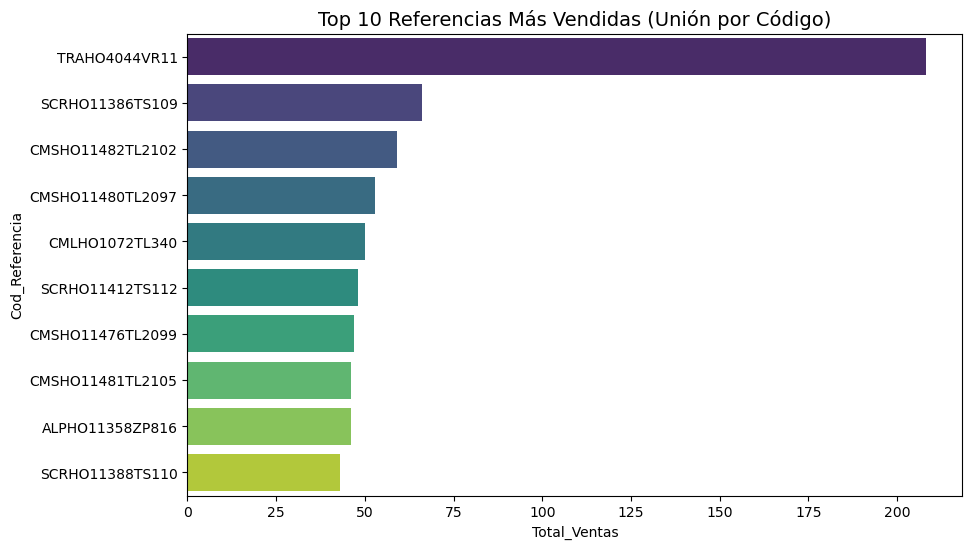

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

with engine.connect() as connection:
    # 1. Cargamos las columnas necesarias de ambas tablas
    # Usamos TRIM para asegurar que no haya espacios invisibles que rompan la unión
    df_ventas = pd.read_sql(text("SELECT TRIM(Talla_Solicitada) as Talla, Referencia_Id_Referencia FROM t_ventas"), connection)
    df_refs = pd.read_sql(text("SELECT TRIM(Cod_Referencia) as Cod_Referencia, Id_Referencia FROM t_referencias"), connection)

# NOTA: Si en tu base 'Referencia_Id_Referencia' contiene el CÓDIGO (ej. "REF-001") 
# y no el ID numérico, este cruce es el correcto:

# 2. Intentamos la unión por la columna de código
# Ajustamos nombres si es necesario: suponiendo que Referencia_Id_Referencia guarda el código
df_final = pd.merge(
    df_ventas, 
    df_refs, 
    left_on='Referencia_Id_Referencia', 
    right_on='Cod_Referencia', 
    how='inner'
)

if df_final.empty:
    print("❌ Sigue sin haber coincidencias.")
    print("Muestra de Ventas:", df_ventas['Referencia_Id_Referencia'].unique()[:5])
    print("Muestra de Referencias:", df_refs['Cod_Referencia'].unique()[:5])
else:
    # 3. Si hay datos, graficamos el Top 10
    top_10 = df_final['Cod_Referencia'].value_counts().head(10).reset_index()
    top_10.columns = ['Cod_Referencia', 'Total_Ventas']

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_10, x='Total_Ventas', y='Cod_Referencia', hue='Cod_Referencia', palette='viridis', legend=False)
    plt.title('Top 10 Referencias Más Vendidas (Unión por Código)', fontsize=14)
    plt.show()


In [39]:
from sqlalchemy import text
import pandas as pd

tablas_auditadas = ['t_ciudades', 't_clientes', 't_referencias']

print("🔄 COMPARATIVA DE RECUPERACIÓN DE DATOS\n" + "="*50)

with engine.connect() as connection:
    for tabla in tablas_auditadas:
        print(f"\n📌 TABLA: {tabla}")
        
        # 1. Verificamos las columnas actuales
        res_cols = connection.execute(text(f"SHOW COLUMNS FROM {tabla}"))
        columnas = [row[0] for row in res_cols]
        print(f"   Variables actuales: {', '.join(columnas)}")
        
        # 2. Mostramos una muestra de los datos recuperados
        # Buscamos la columna de "Nombre" que acabamos de llenar
        col_nombre = [c for c in columnas if 'NOM' in c.upper()][0]
        
        query_muestra = text(f"SELECT {col_nombre} FROM {tabla} WHERE {col_nombre} IS NOT NULL LIMIT 5")
        muestra = connection.execute(query_muestra).fetchall()
        
        if muestra:
            print(f"   ✅ DATOS RECUPERADOS (Muestra):")
            for m in muestra:
                print(f"      - {m[0]}")
        else:
            print(f"   ⚠️ ADVERTENCIA: La columna '{col_nombre}' existe pero sigue vacía.")

print("\n" + "="*50)
print("✨ Si ves nombres reales arriba, ¡la base está lista para la Ciencia de Datos!")


🔄 COMPARATIVA DE RECUPERACIÓN DE DATOS

📌 TABLA: t_ciudades
   Variables actuales: Id_Ciudad, Nom_Ciudad
   ✅ DATOS RECUPERADOS (Muestra):
      - MEDELLIN
      - BARRANQUILLA
      - BOGOTA, D.C.
      - CARTAGENA
      - TUNJA

📌 TABLA: t_clientes
   Variables actuales: Id_Cliente, Nom_Cliente, Documento_Cliente, Dir_Cliente, Ciudad_Id_Ciudad, Correo_Cliente, Tipo_Cliente, Ingresado_Por, Fecha_Ingreso, Fechadia, Fechames, Fechaano
   ✅ DATOS RECUPERADOS (Muestra):
      - MAYERLY
      - ALEX
      - AMAURY ESTEBAN
      - SARA
      - KAREN

📌 TABLA: t_referencias
   Variables actuales: Id_Referencia, Cod_Referencia, Nom_Referencia, Fecha_Creacion, Coleccion_Id_Coleccion, Categoria_Id_Categoria_Prod, SubCategoria_Id_Subcategoria_Prod, Costo_Proyectado_Pref, V_Mano_Obra_Ref, PVP_Ref, P_Mayor, Ref_Publicada, Tipo_Referencia, Creado_Por, Modificado_Por, Ref_generica
   ✅ DATOS RECUPERADOS (Muestra):
      - CMC  LINO BLANCO, BT BLANCO,   LOGO BORDADO GRIS PLATA
      - CML LINO BLANCO

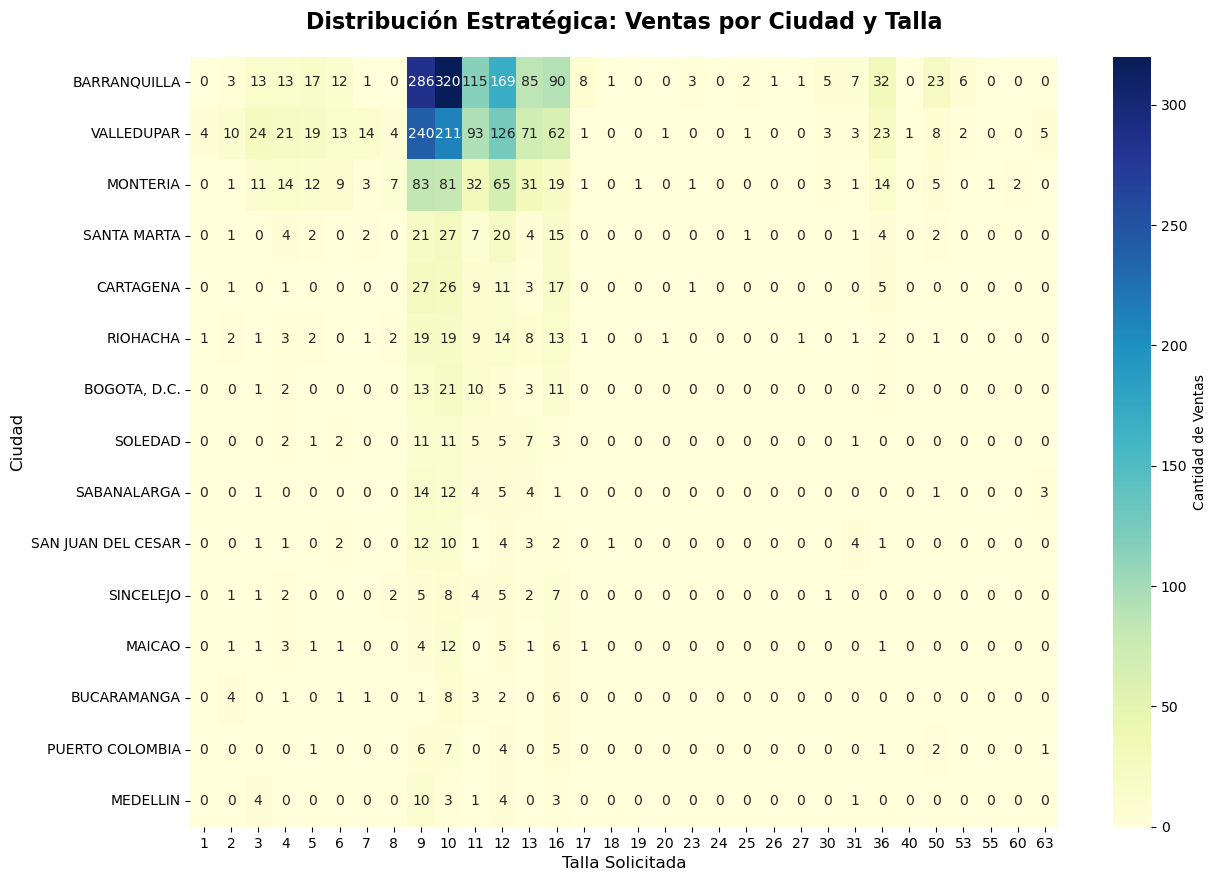

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Consulta SQL usando los nuevos nombres recuperados
query_heatmap = text("""
    SELECT 
        ciud.Nom_Ciudad AS Ciudad,
        v.Talla_Solicitada AS Talla,
        COUNT(v.Id_Venta) AS Unidades
    FROM t_ventas v
    JOIN t_clientes c ON v.Cliente_Id_Cliente = c.Id_Cliente
    JOIN t_ciudades ciud ON c.Ciudad_Id_Ciudad = ciud.Id_Ciudad
    WHERE v.Talla_Solicitada IS NOT NULL AND v.Talla_Solicitada != ''
    GROUP BY ciud.Nom_Ciudad, v.Talla_Solicitada
""")

with engine.connect() as connection:
    df_heatmap = pd.read_sql(query_heatmap, connection)

# 2. Pivotar los datos para el formato de mapa de calor
# Filas: Ciudades | Columnas: Tallas | Valores: Conteo de ventas
pivot_table = df_heatmap.pivot(index='Ciudad', columns='Talla', values='Unidades').fillna(0)

# Filtramos solo las 15 ciudades con más movimiento para que sea legible
top_15_ciudades = pivot_table.sum(axis=1).nlargest(15).index
pivot_table = pivot_table.loc[top_15_ciudades]

# 3. Dibujar el Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Cantidad de Ventas'})

plt.title('Distribución Estratégica: Ventas por Ciudad y Talla', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Talla Solicitada', fontsize=12)
plt.ylabel('Ciudad', fontsize=12)
plt.show()


In [41]:
import datetime as dt

# 1. Extraemos la data necesaria
query_rfm = text("""
    SELECT 
        Cliente_Id_Cliente as id,
        MAX(Fecha_Solicitud) as ultima_compra,
        COUNT(Id_Venta) as frecuencia,
        SUM(Valor_Final) as monetario
    FROM t_ventas
    GROUP BY Cliente_Id_Cliente
""")

with engine.connect() as connection:
    df_rfm = pd.read_sql(query_rfm, connection)

# 2. Calculamos la Recencia en días
df_rfm['ultima_compra'] = pd.to_datetime(df_rfm['ultima_compra'])
fecha_actual = df_rfm['ultima_compra'].max() + dt.timedelta(days=1)
df_rfm['recencia'] = (fecha_actual - df_rfm['ultima_compra']).dt.days

# 3. Asignamos puntajes del 1 al 5 (Quintiles)
# Nota: En Recencia, un número menor es mejor (5), en F y M, mayor es mejor (5).
df_rfm['R'] = pd.qcut(df_rfm['recencia'], 5, labels=[5, 4, 3, 2, 1])
df_rfm['F'] = pd.qcut(df_rfm['frecuencia'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
df_rfm['M'] = pd.qcut(df_rfm['monetario'], 5, labels=[1, 2, 3, 4, 5])

# 4. Segmentación Estratégica
def segmentar(df):
    score = int(str(df['R']) + str(df['F']))
    if score >= 54: return 'Campeones (VIP)'
    if score >= 43: return 'Clientes Leales'
    if score >= 33: return 'Potencialmente Leales'
    if score >= 22: return 'Promesas / Nuevos'
    return 'En Riesgo / Perdidos'

df_rfm['Segmento'] = df_rfm.apply(segmentar, axis=1)

# Resumen para el cliente
resumen_rfm = df_rfm['Segmento'].value_counts().reset_index()
print("📊 SEGMENTACIÓN DE CLIENTES ALL BAUTE")
print(resumen_rfm)


📊 SEGMENTACIÓN DE CLIENTES ALL BAUTE
                Segmento  count
0      Promesas / Nuevos    399
1        Clientes Leales    390
2  Potencialmente Leales    380
3   En Riesgo / Perdidos    362
4        Campeones (VIP)    157


In [42]:
import plotly.express as px

# 1. Preparar data para el Dashboard (usando el merge que ya validamos)
with engine.connect() as connection:
    query_dash = text("""
        SELECT ciu.Nom_Ciudad, v.Talla_Solicitada, SUM(v.Valor_Final) as Ingresos
        FROM t_ventas v
        JOIN t_clientes c ON v.Cliente_Id_Cliente = c.Id_Cliente
        JOIN t_ciudades ciu ON c.Ciudad_Id_Ciudad = ciu.Id_Ciudad
        GROUP BY ciu.Nom_Ciudad, v.Talla_Solicitada
    """)
    df_dash = pd.read_sql(query_dash, connection)

# 2. Gráfico Interactivo de Ingresos por Ciudad
fig1 = px.bar(df_dash.groupby('Nom_Ciudad')['Ingresos'].sum().nlargest(10).reset_index(), 
             x='Nom_Ciudad', y='Ingresos', 
             title='💰 Top 10 Ciudades por Generación de Ingresos',
             color='Ingresos', color_continuous_scale='Viridis',
             template='plotly_white')

# 3. Gráfico Interactivo de Tallas (Sunburst - Muy elegante para presentaciones)
fig2 = px.sunburst(df_dash[df_dash['Nom_Ciudad'].isin(df_dash.groupby('Nom_Ciudad')['Ingresos'].sum().nlargest(5).index)], 
                  path=['Nom_Ciudad', 'Talla_Solicitada'], values='Ingresos',
                  title='🎯 Distribución Talla/Ciudad (Top 5 Ciudades)',
                  color='Ingresos', color_continuous_scale='RdBu')

fig1.show()
fig2.show()


In [44]:
import plotly.express as px

fig = px.treemap(df_rfm, 
                 path=['Segmento'], 
                 values='monetario', # El tamaño depende de cuánto dinero dejan
                 color='recencia', # El color depende de qué tan reciente compraron
                 color_continuous_scale='RdYlGn_r',
                 title='Distribución de Valor por Segmento de Cliente')
fig.show()


In [45]:
df_plot = df_rfm['Segmento'].value_counts(normalize=True).reset_index()
df_plot.columns = ['Segmento', 'Porcentaje']
df_plot['Porcentaje'] *= 100

fig = px.bar(df_plot, x='Porcentaje', y='Segmento', orientation='h',
             text=df_plot['Porcentaje'].apply(lambda x: f'{x:.1f}%'),
             title='Composición de la Cartera de Clientes (%)',
             color='Segmento', color_discrete_sequence=px.colors.qualitative.Prism)
fig.show()


In [47]:
import plotly.graph_objects as go

# 1. Preparamos los datos ordenados (de más clientes a menos, o por jerarquía)
# Es mejor ordenarlos para que el embudo tenga sentido visual
resumen_ordenado = df_rfm['Segmento'].value_counts().reset_index()
resumen_ordenado.columns = ['Segmento', 'Cantidad']

fig = go.Figure(go.Funnel(
    y = resumen_ordenado['Segmento'],
    x = resumen_ordenado['Cantidad'],
    textinfo = "value+percent initial",
    marker = {
        "color": ["#1a2a6c", "#b21f1f", "#fdbb2d", "#3a7bd5", "#00d2ff"],
        "line": {"width": [2, 2, 2, 2, 2], "color": "white"}
    },
    connector = {"line": {"color": "royalblue", "dash": "dot", "width": 3}}
))

fig.update_layout(
    title_text='<b>Embudo de Valor de Clientes - All Baute</b>',
    title_font_size=20,
    template='plotly_white'
)

fig.show()


In [ ]:
import pandas as pd
from sqlalchemy import text

# Fecha de corte para el respaldo 2024
fecha_respaldo = '2024-01-01'
nombre_archivo = 'Auditoria_Respaldo_AllBaute_2024.xlsx'

print(f"📦 Generando Respaldo y Auditoría de Datos: {nombre_archivo}...")

with engine.connect() as connection:
    # --- PESTAÑA 1: REPORTE DE VENTAS CON NOMBRES (Ventas + Clientes + Ciudad) ---
    query_ventas = text(f"""
        SELECT v.Id_Venta, v.Fecha_Solicitud, c.Nom_Cliente, ciud.Nom_Ciudad, 
               v.Talla_Solicitada, v.Valor_Final, v.Factura_Id_Factura
        FROM t_ventas v
        JOIN t_clientes c ON v.Cliente_Id_Cliente = c.Id_Cliente
        JOIN t_ciudades ciud ON c.Ciudad_Id_Ciudad = ciud.Id_Ciudad
        WHERE v.Fecha_Solicitud >= '{fecha_respaldo}'
    """)
    df_ventas = pd.read_sql(query_ventas, connection)

    # --- PESTAÑA 2: CONCILIACIÓN PENDIENTE (Solo las ventas con problemas) ---
    query_pendientes = text(f"""
        SELECT v.Id_Venta, v.Fecha_Solicitud, c.Nom_Cliente, v.Valor_Final
        FROM t_ventas v
        JOIN t_clientes c ON v.Cliente_Id_Cliente = c.Id_Cliente
        WHERE (v.Factura_Id_Factura IS NULL OR v.Factura_Id_Factura = 0 OR v.Factura_Id_Factura = '')
        AND v.Fecha_Solicitud >= '{fecha_respaldo}'
    """)
    df_pendientes = pd.read_sql(query_pendientes, connection)

    # --- PESTAÑA 3: INVENTARIO POR TALLA (Consistencia) ---
    query_inv = text("""
        SELECT t.Nom_Talla, SUM(i.Cantidad) as Stock_Total
        FROM t_tallas t
        LEFT JOIN t_inventario i ON t.Id_Talla = i.Id_Talla
        GROUP BY t.Nom_Talla
    """)
    df_inventario = pd.read_sql(query_inv, connection)

    # --- PESTAÑA 4: SEGMENTACIÓN DE CLIENTES (RFM Actual) ---
    query_rfm = text(f"""
        SELECT c.Nom_Cliente, COUNT(v.Id_Venta) as Frecuencia, SUM(v.Valor_Final) as Monetario
        FROM t_ventas v
        JOIN t_clientes c ON v.Cliente_Id_Cliente = c.Id_Cliente
        WHERE v.Fecha_Solicitud >= '{fecha_respaldo}'
        GROUP BY c.Nom_Cliente
    """)
    df_rfm = pd.read_sql(query_rfm, connection)
# --- ACTUALIZACIÓN DEL RESPALDO CON EL HALLAZGO REAL ---
with engine.connect() as connection:
    query_hallazgo = text(f"""
        SELECT 
            v.Id_Venta, 
            v.Fecha_Solicitud, 
            v.Factura_Id_Factura as ID_Factura_Fantasma, 
            v.Valor_Final,
            c.Nom_Cliente
        FROM t_ventas v
        LEFT JOIN t_clientes c ON v.Cliente_Id_Cliente = c.Id_Cliente
        LEFT JOIN t_facturas f ON v.Factura_Id_Factura = f.Id_Factura
        WHERE f.Id_Factura IS NULL 
        AND v.Fecha_Solicitud >= '{fecha_respaldo}'
    """)
    df_fugas_reales = pd.read_sql(query_hallazgo, connection)

# Guardar en el Excel (Pestaña 2)
# ... (usa el mismo bloque de pd.ExcelWriter que ya tienes)

# Guardar todo en un solo archivo Excel
with pd.ExcelWriter(nombre_archivo) as writer:
    df_ventas.to_excel(writer, sheet_name='Ventas_Auditadas', index=False)
    df_pendientes.to_excel(writer, sheet_name='Fugas_Pendientes', index=False)
    df_inventario.to_excel(writer, sheet_name='Estado_Inventario', index=False)
    df_rfm.to_excel(writer, sheet_name='Segmentacion_Clientes', index=False)

print(f"✅ ¡Respaldo completado! El archivo '{nombre_archivo}' ya está listo en tu carpeta.")


📦 Generando Respaldo y Auditoría de Datos: Auditoria_Respaldo_AllBaute_2024.xlsx...
✅ ¡Respaldo completado! El archivo 'Auditoria_Respaldo_AllBaute_2024.xlsx' ya está listo en tu carpeta.


In [50]:
    # Esta versión busca NULL, vacíos, ceros y espacios en blanco
    query_pendientes = text(f"""
        SELECT v.Id_Venta, v.Fecha_Solicitud, c.Nom_Cliente, v.Valor_Final, v.Factura_Id_Factura
        FROM t_ventas v
        JOIN t_clientes c ON v.Cliente_Id_Cliente = c.Id_Cliente
        WHERE v.Factura_Id_Factura IS NULL 
           OR v.Factura_Id_Factura = 0 
           OR v.Factura_Id_Factura = '' 
           OR TRIM(v.Factura_Id_Factura) = ''
        AND v.Fecha_Solicitud >= '{fecha_respaldo}'
    """)
